**Gradient Descent** is the fundamental optimization algorithm used to train Machine Learning models, including Linear Regression, Logistic Regression, and Deep Neural Networks.

Its entire goal is to **minimize a "Loss Function"** (which measures how wrong your model's predictions are) by iteratively tweaking the model's internal parameters (weights and biases) until it finds the best possible settings.

---

- **The Intuition: "The Foggy Mountain"**

- Imagine you are standing near the top of a mountain inside a thick fog. You cannot see the bottom, but you want to reach the lowest point of the valley. How do you do it?
    - 1. You feel the slope of the ground under your feet to see which direction points **downward**.
    - 2. You take a step in that downward direction.
    - 3. You stop, feel the slope again, and take another step.
    - 4. You repeat this process until the ground becomes completely flat. When it's flat, you have arrived at the bottom (the minimum loss).

---

- **The Mathematical Engine**

- To translate this analogy into Python code and math, we use three key concepts:

- **1. The Loss Function ($L$)**
    - This is our mountain. It takes the model's current guesses, compares them to the true values, and outputs a score of how inaccurate the model is. A common one is **Mean Squared Error (MSE)**.

- **2. The Gradient ($\nabla L$)**

- The gradient is a vector of partial derivatives. In simple terms, it tells you **the slope of the mountain**.
    * It points in the direction of the *steepest ascent* (going up).
    * Therefore, to go *down*, we move in the **opposite direction** of the gradient (negative gradient).

- **3. The Learning Rate ($\alpha$)**

- The learning rate is the **size of the step** you take down the mountain.
    * **If $\alpha$ is too small:** You take tiny baby steps. The model will take forever to train (it converges too slowly).
    * **If $\alpha$ is too large:** You take massive leaps. You might overshoot the valley completely and bounce back and forth, failing to ever find the bottom (divergence).

---

- **Step-by-Step Algorithm Loop**

- For every iteration in your training process, Gradient Descent performs the following steps:
    - 1. **Predict:** Pass data through the model using current parameters ($w$).
    - 2. **Evaluate:** Compute the loss to see how far off the predictions are.
    - 3. **Calculate Gradient:** Find the derivative of the loss with respect to the parameters ($\frac{\partial L}{\partial w}$).
    - 4. **Update Parameters:** Change the parameters using the update rule:

$$w_{\text{new}} = w_{\text{old}} - (\alpha \times \text{gradient})$$

---

- **Three Flavors of Gradient Descent**

- Depending on how much data you feed into the algorithm at once, Gradient Descent changes behavior:

| Type | How it Works | Pros | Cons |
| --- | --- | --- | --- |
| **Batch Gradient Descent** | Looks at **all** data rows before taking a single step. | Stable, smooth path to the minimum. | Extremely slow and memory-heavy on large datasets. |
| **Stochastic (SGD)** | Looks at **only 1 random row** before taking a step. | Extremely fast; jumps out of local minima easily. | The path is highly erratic and bounces around constantly. |
| **Mini-Batch** | Looks at a **small group** (e.g., 32, 64, or 256 rows) at a time. | **The Industry Standard.** Best balance of speed and stability. | Requires tuning the "batch size" parameter. |

---

- **Visualizing the Progress**

- If you look at your loss over time during a successful training run, it follows a curve that flattens out:

```
Loss
  |  \
  |   \
  |    '.
  |      '._________________  <-- Gradient becomes zero (Flat ground)
  +--------------------------
                     Iterations

```

- **Why this matters for an MLOps/Data Engineer**

- While data scientists focus on tuning the learning rate, as an engineer building data pipelines, Gradient Descent affects your infrastructure choice.
    * Running full **Batch** gradient descent requires loading whole database tables into memory, which crashes workers.
    * Implementing **Mini-Batch** processing allows your training pipelines to stream data incrementally out of your data warehouse without blowing up RAM.

![Gradient Descent](../Images/Gradient_Descent.png)

> Note : If a function has a unique global minimum, this procedure is likely to find it. If a function has multiple (local) minima, this procedure might “find” the wrong one of them, in which case you might rerun the procedure from different starting points. If a function has no minimum, then it’s possible the procedure might go on forever.

In [55]:
from typing import List

In [56]:
Vector = List[float]

def dot(v: Vector, w: Vector) -> float:
    if len(v) == len(w):
        res = sum( v_i * w_i for v_i, w_i in zip(v, w))

    return res

def sum_of_squares(v: Vector) -> float:
    """Computes the sum of squared elements in v"""
    
    return dot(v, v)

## **Estimating the Gradient**

In [57]:
from typing import Callable

In [58]:
def difference_quotient(f: Callable[[float], float],
                       x: float, 
                       h: float):
    return (f(x + h) - f(x)) / h

![Approximating a derivative with a difference quotient](../Images/Approximating_a_Derivative.png)

In data science and machine learning, this is the exact geometric math that allows us to compute gradients during **Gradient Descent**.

Here is a breakdown of the concept shown in your image.

---

- **1. The Core Problem: Secant vs. Tangent Line**

- On a curved line, the slope is constantly changing.
    * **The Goal (The Green Line):** We want to find the **derivative** at exactly one point, $(x, f(x))$. This is represented by the green tangent line, which touches the curve at just that single spot. Finding its exact slope algebraically requires calculus.
    * **The Approximation (The Purple Line):** Since finding the slope at a single point is difficult without limits, we pick a second point further down the curve at a distance of $h$. This gives us the point $(x+h, f(x+h))$. The purple line connecting these two points is called a **secant line**.

---

- **2. The Difference Quotient Math**

To find the slope of that purple secant line, we use the classic algebraic formula for a slope: $\text{Slope} = \frac{\text{Rise}}{\text{Run}}$.

- Looking closely at the triangle drawn in purple on your image:
    * **The Rise (Vertical Change):** The distance between the two vertical outputs on the y-axis is $f(x+h) - f(x)$. *(Note: In your image, the curve is sloping downward, so this change is negative, but the math structure remains identical).*
    * **The Run (Horizontal Change):** The distance between your two inputs on the x-axis is simply $h$ (since $(x + h) - x = h$).

- When you put these together, you get the **Difference Quotient**:
    - $$\text{Slope of Secant Line} \approx \frac{f(x+h) - f(x)}{h}$$

This fraction is our **approximation of the derivative**.

---

- **3. How the Approximation Becomes Exact**

Right now, looking at your image, there is a clear visual gap between the green line (the true derivative) and the purple line (our approximation). The purple line isn't quite steep enough.

- To make the approximation accurate, we change the value of $h$:
    - 1. Imagine sliding the second point $(x+h, f(x+h))$ leftward along the grey curve, making the gap $h$ smaller and smaller.
    - 2. As $h$ shrinks (e.g., from $1.0 \rightarrow 0.1 \rightarrow 0.00001$), the purple triangle shrinks, and the purple line rotates.
    - 3. Eventually, as $h$ approaches zero ($h \to 0$), the purple secant line lands perfectly on top of the green tangent line.

- This transition from an approximation to an exact value is defined as the formal derivative:
    - $$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

---

- **Why this matters in Python and Machine Learning**

When you are writing optimization algorithms from scratch and you don't want to calculate complex symbolic derivatives by hand, you can use this exact difference quotient method in your code to estimate slopes numerically.

It's called **Numerical Differentiation**:

```python
def estimate_derivative(f, x, h=0.00001):
    """Approximates the derivative of function 'f' at point 'x' 
    using the finite difference quotient shown in the image."""
    return (f(x + h) - f(x)) / h

```

By setting a tiny $h$ (like `1e-5`), your code calculates a purple line so close to the green line that the error is practically zero. This tells your Gradient Descent algorithm exactly which way is "downhill"!

In [59]:
import matplotlib.pyplot as plt

In [60]:
def square(x: float) -> float:
    return x * x

def derivative(x: float) -> float:
    return 2 * x

In [61]:
xs = range(-10, 11)
actuals = [derivative(x) for x in xs]
estimates = [difference_quotient(square, x, h=0.001) for x in xs]

In [62]:
actuals

[-20,
 -18,
 -16,
 -14,
 -12,
 -10,
 -8,
 -6,
 -4,
 -2,
 0,
 2,
 4,
 6,
 8,
 10,
 12,
 14,
 16,
 18,
 20]

In [63]:
estimates

[-19.998999999984335,
 -17.998999999988996,
 -15.999000000007868,
 -13.999000000005424,
 -11.99900000000298,
 -9.999000000004088,
 -7.998999999999867,
 -5.998999999999199,
 -3.9989999999994197,
 -1.998999999999973,
 0.001,
 2.0009999999996975,
 4.000999999999699,
 6.000999999999479,
 8.0010000000037,
 10.001000000002591,
 12.001000000005035,
 14.00100000000748,
 16.000999999988608,
 18.000999999983947,
 20.000999999993496]

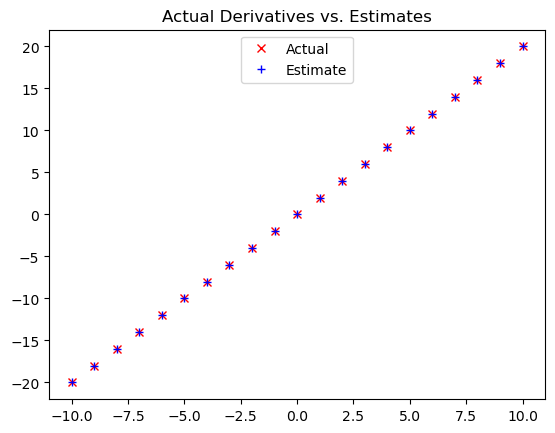

In [64]:
plt.title("Actual Derivatives vs. Estimates")
plt.plot(xs, actuals, 'rx', label='Actual')
plt.plot(xs, estimates, 'b+', label='Estimate')
plt.legend(loc=9)
plt.show()

In [65]:
def partial_difference_quotient(f: Callable[[Vector], float],
                               v: Vector,
                               i: int,
                               h: float) -> float:
    """Returns the i-th partial difference quotient of f at v"""

    w = [v_i + (h if j == i else 0) for j, v_i in enumerate(v)]

    return (f(w) - f(v)) / h

In [66]:
def estimate_gradient(f: Callable[[Vector], float],
                     v: Vector,
                     h: float= 0.0001) -> Vector:
    
    return [partial_difference_quotient(f, v, i, h) for i in range(len(v))]

## **Using the Gradient**

In [67]:
import random

In [68]:
def add_vectors(v: Vector, u: Vector) -> Vector:
    """add two equal vector by size, adding each element to the correspandent element in the second vector"""
    if len(v) != len(u): raise ValueError("The Vectors must be in the same leghts")
    
    return [v + u for v, u in zip(v, u)]

def scalar_multiply(v: Vector, c: float) -> Vector:
    """Multiply each element in vector by a scaler"""
    return [v_i * c for v_i in v]

def dot(v: Vector, w: Vector) -> float:
    """Computes v_1 * w_1 + ... + v_n * w_n"""
    assert len(v) == len(w), "The vector must be in same size"
    
    return sum(v_i * w_i for v_i, w_i in zip(v, w))

def sum_of_square(v: Vector) -> Vector:
    """Returns v_1 * v_1 + ... + v_n * v_n"""

    return dot(v, v)

def magnitude(v: Vector) -> float:
    """Returns the magnitude (or length) of v"""
    
    return math.sqrt(sum_of_square(v))


def distance(v: Vector, w: Vector) -> float:
    """Computes the distance between v and w"""

    return magnitude(sub_vectors(v, w))

In [69]:
def gradient_step(v: Vector, gradient: Vector, step_size: float) -> Vector:
    """Moves `step_size` in the `gradient` direction from `v`"""

    assert len(v) == len(gradient), "The vectore must be equal in size"
    step = scalar_multiply(gradient, step_size)
    return add_vectors(v, step)

def sum_of_squares_gradient(v: Vector) -> Vector:

    return [2 * v_i for v_i in v]

In [70]:
# pick a random starting point
v = [random.uniform(-10, 10) for i in range(3)]

for epoch in range(1000):
    grad = sum_of_squares_gradient(v)
    v = gradient_step(v, grad, -0.01)
    print(epoch, v)

0 [6.553203369474879, 0.6855348193306575, -3.8880655429434885]
1 [6.422139302085381, 0.6718241229440444, -3.8103042320846185]
2 [6.293696516043673, 0.6583876404851635, -3.7340981474429262]
3 [6.1678225857228, 0.6452198876754602, -3.659416184494068]
4 [6.044466134008344, 0.6323154899219511, -3.5862278608041867]
5 [5.923576811328177, 0.619669180123512, -3.514503303588103]
6 [5.805105275101614, 0.6072757965210418, -3.444213237516341]
7 [5.689003169599581, 0.595130280590621, -3.375328972766014]
8 [5.57522310620759, 0.5832276749788086, -3.3078223933106936]
9 [5.463718644083438, 0.5715631214792324, -3.24166594544448]
10 [5.3544442712017695, 0.5601318590496477, -3.17683262653559]
11 [5.247355385777734, 0.5489292218686548, -3.1132959740048785]
12 [5.142408278062179, 0.5379506374312817, -3.051030054524781]
13 [5.0395601125009355, 0.527191624682656, -2.9900094534342854]
14 [4.938768910250917, 0.5166477921890029, -2.9302092643655997]
15 [4.839993532045899, 0.5063148363452229, -2.8716050790782877]

## **Choosing the Right Step Size**

When optimizing a machine learning model or minimizing a loss function using Gradient Descent, calculating the direction (the gradient) is only half the battle. The other crucial half is deciding **how big of a step** to take in that direction.

In your difference quotient formula, if the gradient tells you which way to move, the **step size** ($\alpha$, also known as the learning rate) dictates the length of your leap.

Here is how the three primary strategies for choosing the right step size work, along with their trade-offs.

---

- **1. Using a Fixed Step Size**

This is the simplest approach. You pick a constant value for the learning rate (such as $\alpha = 0.01$ or $\alpha = 0.001$) and keep it exactly the same across every single iteration of your optimization loop.

* **How it feels:** Walking down a mountain taking strides of exactly 1 meter every single time, regardless of whether the slope is steep, rocky, or flattening out.
* **The Problem (Overshooting):** When you are far away from the minimum, a fixed step size might work well. However, as you approach the very bottom of the valley (the minimum), a step size that is too large will cause the model to jump *over* the bottom and land on the opposite slope. It will endlessly bounce back and forth without ever settling down.
    * **Pros:** Extremely easy to implement; requires very little computational overhead per step.
    * **Cons:** Highly sensitive to your initial guess. If you pick a size slightly too big, the algorithm diverges (explodes); if it's too small, training takes forever.

---

- **2. Gradually Shrinking the Step Size Over Time (Learning Rate Decay)**

To solve the overshooting problem of fixed steps, you can implement a schedule where the step size automatically gets smaller as the iterations progress. This is often called **Learning Rate Decay** or **Learning Rate Annealing**.

* **How it feels:** Sprinting down the mountain when you are near the top, but slowing down to careful, tiny baby steps as you get closer to the bottom so you don't trip or overshoot the destination.
* **Mathematical Schedules:** You can shrink it using different formulas, such as:
* **Time-based decay:** $\alpha_{\text{new}} = \frac{\alpha_0}{1 + \text{decay\_rate} \times \text{iteration}}$
* **Exponential decay:** Decreasing the step size by a fixed percentage (e.g., cutting it in half) every 10 epochs.
    * **Pros:** Allows for fast initial progress while ensuring the algorithm stabilizes and accurately pinpoints the minimum at the end.
    * **Cons:** Introduces more hyperparameters to tune. Now you don't just have to pick the starting step size, you also have to figure out the exact speed at which it should shrink.

---

- **3. Choosing the Step Size that Minimizes the Objective Function (Line Search)**

This is an adaptive approach often referred to as **Exact Line Search**. Instead of using a fixed rule or a clock-based schedule, the algorithm performs a mini-optimization problem *at each individual step*.

Once the gradient direction is established, the algorithm looks forward along that line and calculates: *"If I could travel any distance along this specific trajectory, exactly how far should I go to achieve the lowest possible loss right now?"*

* **How it feels:** Standing on a slope, looking down the exact line of the path, and throwing a small ball forward to find the absolute lowest dip in your immediate field of view—then jumping exactly to that dip.
    * **Pros:** Highly efficient in terms of the number of steps required to reach the minimum. It takes mathematically optimal paths and avoids the guesswork of tuning manual decay schedules.
    * **Cons:** **Extremely expensive computationally.** Calculating the absolute best step size at *every single turn* requires evaluating your loss function multiple times per iteration. In large-scale machine learning or deep learning with millions of data rows, this strategy is practically impossible to use because it destroys system performance.

---

- **Summary Checklist for MLOps and Engineering**

When building real-world machine learning systems, you will almost always see a variation of **Strategy 2**.

Modern adaptive optimizers used in frameworks like TensorFlow and PyTorch (such as **Adam** or **RMSprop**) automate this logic. They don't just shrink the step size over time; they dynamically compute unique, shifting step sizes for *every individual parameter* based on how volatile its historical gradients have been.

## **Using Gradient Descent to Fit Models**

In [71]:
inputs = [(x, 20 * x +5) for x in range(-50, 50)]

inputs

[(-50, -995),
 (-49, -975),
 (-48, -955),
 (-47, -935),
 (-46, -915),
 (-45, -895),
 (-44, -875),
 (-43, -855),
 (-42, -835),
 (-41, -815),
 (-40, -795),
 (-39, -775),
 (-38, -755),
 (-37, -735),
 (-36, -715),
 (-35, -695),
 (-34, -675),
 (-33, -655),
 (-32, -635),
 (-31, -615),
 (-30, -595),
 (-29, -575),
 (-28, -555),
 (-27, -535),
 (-26, -515),
 (-25, -495),
 (-24, -475),
 (-23, -455),
 (-22, -435),
 (-21, -415),
 (-20, -395),
 (-19, -375),
 (-18, -355),
 (-17, -335),
 (-16, -315),
 (-15, -295),
 (-14, -275),
 (-13, -255),
 (-12, -235),
 (-11, -215),
 (-10, -195),
 (-9, -175),
 (-8, -155),
 (-7, -135),
 (-6, -115),
 (-5, -95),
 (-4, -75),
 (-3, -55),
 (-2, -35),
 (-1, -15),
 (0, 5),
 (1, 25),
 (2, 45),
 (3, 65),
 (4, 85),
 (5, 105),
 (6, 125),
 (7, 145),
 (8, 165),
 (9, 185),
 (10, 205),
 (11, 225),
 (12, 245),
 (13, 265),
 (14, 285),
 (15, 305),
 (16, 325),
 (17, 345),
 (18, 365),
 (19, 385),
 (20, 405),
 (21, 425),
 (22, 445),
 (23, 465),
 (24, 485),
 (25, 505),
 (26, 525),
 (27, 

In [72]:
def linear_gradient(x: float, y: float, theta: Vector) -> Vector:
    slop, intercept = theta
    predict = slop * x + intercept    # The prediction of the model.
    error = predict - y               # error is (predicted - actual).
    squared_error = error ** 2        # We'll minimize squared error using its gradient.
    grad = [2 * error * x, 2 * error]

    return grad

In [73]:
def sum_vectors(vectors: List[Vector]) -> Vector:
    """increasing dimension of vector by adding each position element by the others in rest vector"""
    # check of empty vectors
    assert vectors, "Please a vectors"

    # check of equal lenght
    vector_lenght = len(vectors[0])
    assert all(len(v) == vector_lenght for v in vectors ), "The Vectors must be in the same leghts"

    # the i-th element of the result is the sum of every vector[i]
    return [sum(v[i] for v in vectors)
                for i in range(vector_lenght)]

def vector_mean(vectors: List[Vector]) -> Vector:
    """Computes the element-wise average"""
    n = len(vectors)
    return scalar_multiply(sum_vectors(vectors), 1/n)

In [74]:
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

learning_rate = 0.0001

In [75]:
for epoch in range(5000):
    # Compute the mean of the gradients
    grad = vector_mean([linear_gradient(x, y, theta) for x, y in inputs])

    # Take a step in that direction
    theta = gradient_step(theta, grad, -learning_rate)

    print(epoch, theta)


0 [2.8932721275470046, 0.8305829721036073]
1 [5.74454672218213, 0.8297061827219413]
2 [8.120513754212642, 0.8291146961576151]
3 [10.10040702285501, 0.8287609245938049]
4 [11.750252048237538, 0.8286052131111716]
5 [13.125067892317652, 0.8286145172733732]
6 [14.270701936120027, 0.8287613011591503]
7 [15.225358799498935, 0.8290226190925304]
8 [16.020874389884373, 0.8293793504486617]
9 [16.683777567025693, 0.8298155620175605]
10 [17.236174828158713, 0.8303179766618595]
11 [17.696487516102323, 0.8308755305493429]
12 [18.080066134721122, 0.8314790041948433]
13 [18.39970225796353, 0.8321207150074764]
14 [18.66605510363251, 0.8327942610902713]
15 [18.888006997283078, 0.8334943077484165]
16 [19.072959580266765, 0.8342164095865952]
17 [19.227080639877254, 0.8349568622627045]
18 [19.35550979289594, 0.8357125789542397]
19 [19.462529881678083, 0.8364809874177385]
20 [19.55170979850109, 0.8372599442084228]
21 [19.626023501085378, 0.8380476631994311]
22 [19.687949188220767, 0.8388426560168998]
23 [19

## **Minibatch and Stochastic Gradient Descent**

In [76]:
from typing import TypeVar, List, Iterator

In [77]:
T = TypeVar('T')

T

~T

In [78]:
def minibatches(dataset: List[T],
               batch_size: int,
               shuffel: bool = True) -> Iterator[List[T]]:
    """Generates `batch_size`-sized minibatches from the dataset"""
    # start indexes 0, batch_size, 2 * batch_size, ...
    batch_starts = [start for start in range(0, len(dataset), batch_size)]

    if shuffel: random.shuffle(batch_starts)

    for start in batch_starts:
        end = start + batch_size
        yield dataset[start: end]

In [79]:
tetha = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(1000):
    for batch in minibatches(inputs, batch_size=20):
        grad = vector_mean([linear_gradient(x, y, theta) for x, y in batch])
        theta = gradient_step(theta, grad, -learning_rate)

    print(epoch, theta)

0 [19.991769763302035, 3.463382001041164]
1 [20.003574183716275, 3.464952164428749]
2 [20.007123244093616, 3.4665896483280036]
3 [20.00932474695754, 3.4682353660602474]
4 [19.997094598533582, 3.469831460552477]
5 [20.002594425746274, 3.4714745446036854]
6 [20.007603213539227, 3.473091857170998]
7 [20.00796528392032, 3.474746853462137]
8 [20.007382373107948, 3.476414637261973]
9 [20.00850988599876, 3.4780583797019555]
10 [19.995858621323077, 3.479632750740716]
11 [20.001615015007104, 3.481262431803511]
12 [19.99708654409562, 3.482895855145432]
13 [20.00102133699151, 3.484524363131274]
14 [19.996711067974914, 3.4861627741729295]
15 [19.992451319784802, 3.4877828036120966]
16 [19.99241282713524, 3.489432921017971]
17 [20.00282230810883, 3.490991336778243]
18 [20.006708344192717, 3.4925986035778838]
19 [20.00685902767987, 3.4942425589065667]
20 [19.998346386774504, 3.4958586769651268]
21 [20.00369193415177, 3.497468491602705]
22 [20.007766476402033, 3.499065480868743]
23 [20.00421986414814

In [80]:
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(100):
    for x, y in inputs:
        grad = linear_gradient(x, y, theta)
        theta = gradient_step(theta, grad, -learning_rate)
    
    print(epoch, theta)

0 [20.106018403456215, -0.060315873909121666]
1 [20.104965077482788, -0.010038245519454389]
2 [20.10392217910005, 0.03973984171690763]
3 [20.1028896426116, 0.08902335029987811]
4 [20.101867365065072, 0.13781719419980026]
5 [20.100855244531008, 0.186126238563427]
6 [20.099853180092676, 0.23395530019901964]
7 [20.098861071836033, 0.28130914805662177]
8 [20.09787882083974, 0.3281925037035628]
9 [20.096906329165307, 0.3746100417952362]
10 [20.095943499847333, 0.42056639054120026]
11 [20.094990236883838, 0.46606613216665266]
12 [20.09404644522667, 0.5111138033693114]
13 [20.09311203077206, 0.5557138957717628]
14 [20.092186900351216, 0.5998708563693145]
15 [20.09127096172104, 0.643589087973392]
16 [20.09036412355493, 0.686872949650544]
17 [20.08946629543368, 0.7297267571570666]
18 [20.088577387836462, 0.7721547833693303]
19 [20.087697312131883, 0.8141612587098105]
20 [20.086825980569177, 0.8557503715689053]
21 [20.085963306269427, 0.8969262687225442]
22 [20.085109203216938, 0.937693055745659